In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
df=pd.read_csv('Real_Estate.csv')
df.head()

,Transaction date,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
0,2012-09-02 16:42:30.519336,13.3,4082.0150,8,25.007059,121.561694,6.488673
1,2012-09-04 22:52:29.919544,35.5,274.0144,2,25.012148,121.546990,24.970725
2,2012-09-05 01:10:52.349449,1.1,1978.6710,10,25.003850,121.528336,26.694267
3,2012-09-05 13:26:01.189083,22.2,1055.0670,5,24.962887,121.482178,38.091638
4,2012-09-06 08:29:47.910523,8.5,967.4000,6,25.011037,121.479946,21.654710


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Transaction date                     414 non-null    object 
 1   House age                            414 non-null    float64
 2   Distance to the nearest MRT station  414 non-null    float64
 3   Number of convenience stores         414 non-null    int64  
 4   Latitude                             414 non-null    float64
 5   Longitude                            414 non-null    float64
 6   House price of unit area             414 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 22.8+ KB


In [41]:
df.duplicated().sum()

np.int64(0)

In [42]:
df.describe()

,House age,Distance to the nearest MRT station,Number of convenience stores,Latitude,Longitude,House price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,18.405072,1064.468233,4.265700,24.973605,121.520268,29.102149
std,11.757670,1196.749385,2.880498,0.024178,0.026989,15.750935
min,0.000000,23.382840,0.000000,24.932075,121.473888,0.000000
25%,9.900000,289.324800,2.000000,24.952422,121.496866,18.422493
50%,16.450000,506.114400,5.000000,24.974353,121.520912,30.394070
75%,30.375000,1454.279000,6.750000,24.994947,121.544676,40.615184
max,42.700000,6306.153000,10.000000,25.014578,121.565321,65.571716


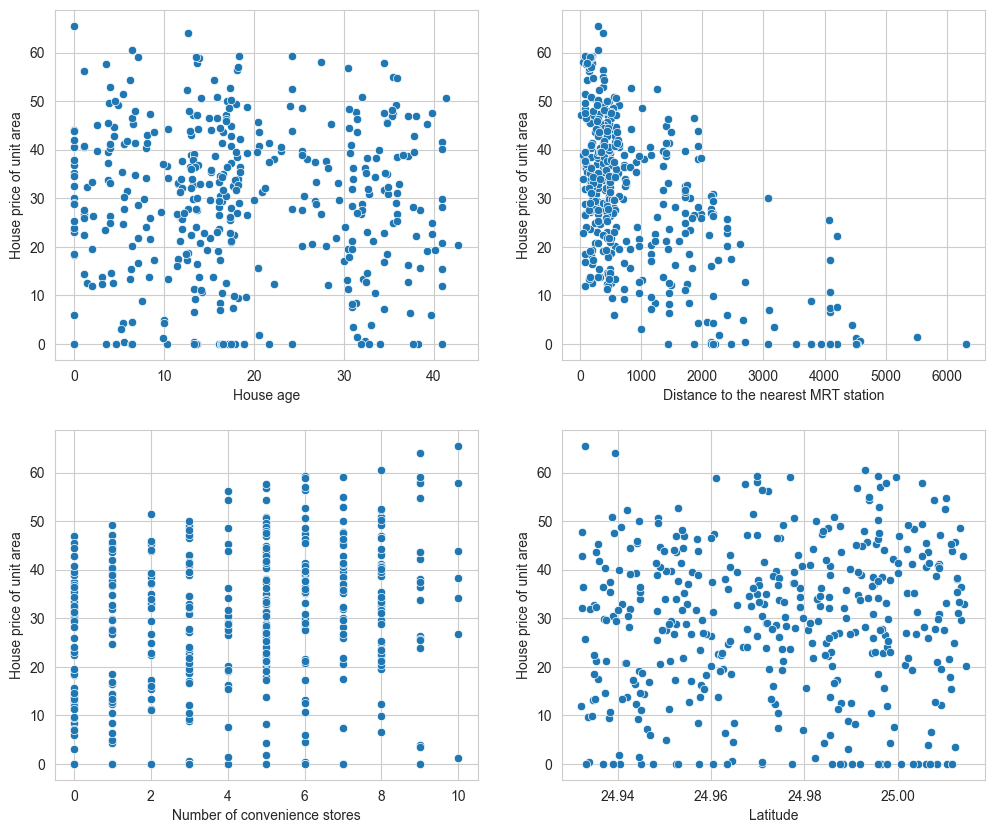

In [43]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.set_style('whitegrid')
sns.scatterplot(data=df, x='House age', y='House price of unit area', ax=axes[0, 0])
sns.scatterplot(data=df, x='Distance to the nearest MRT station', y='House price of unit area', ax=axes[0, 1])
sns.scatterplot(data=df, x='Number of convenience stores', y='House price of unit area', ax=axes[1, 0])
sns.scatterplot(data=df, x='Latitude', y='House price of unit area', ax=axes[1, 1])
plt.show()

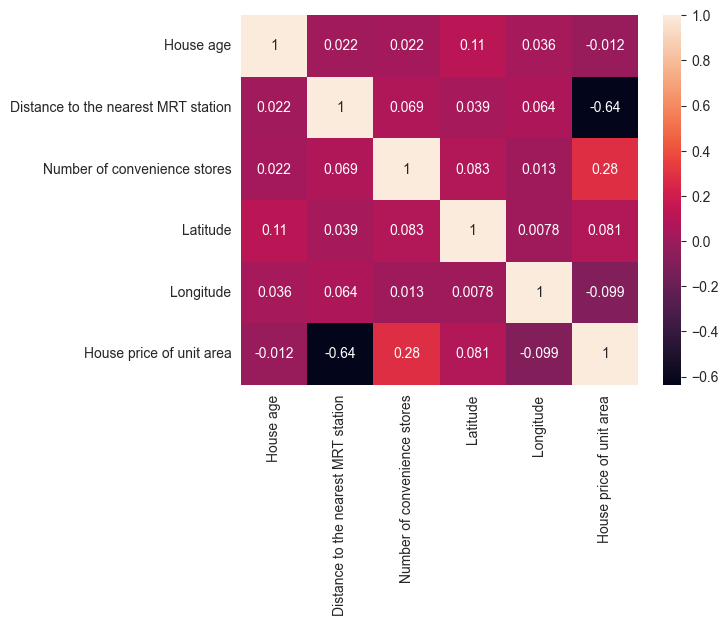

In [44]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

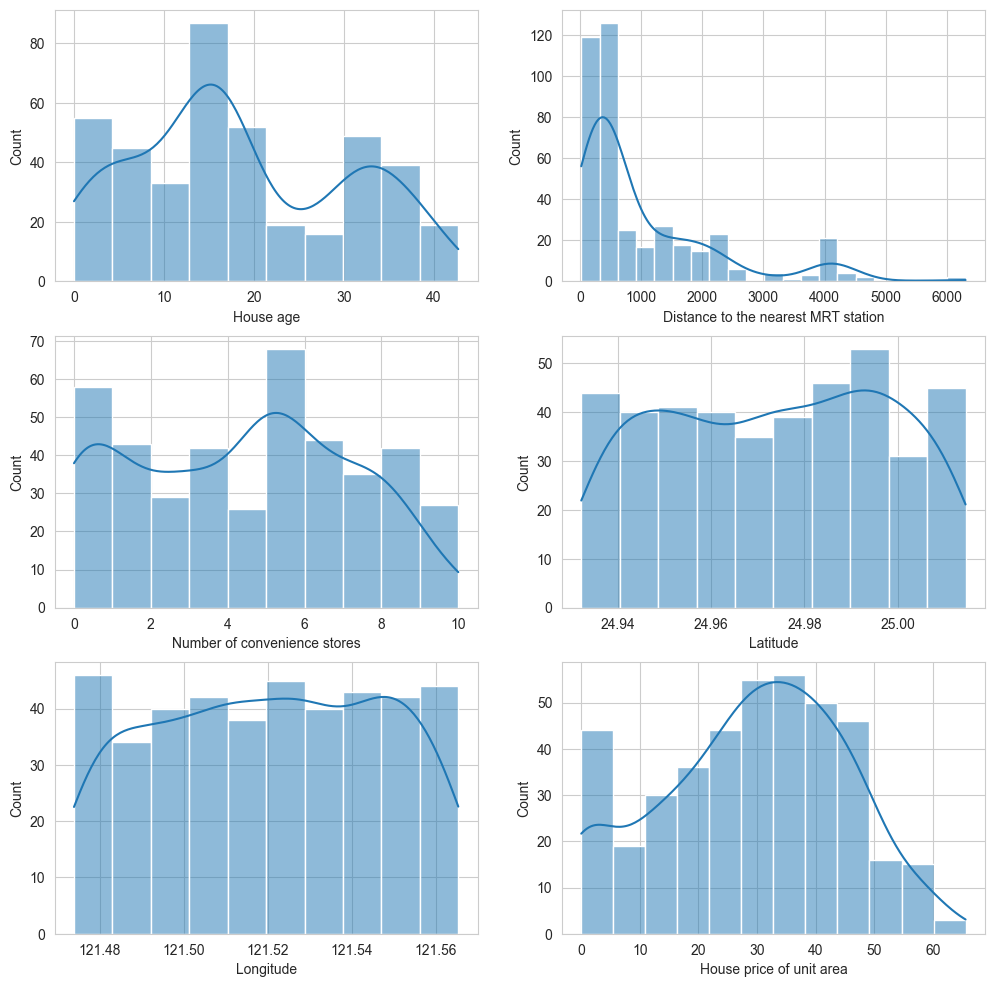

In [45]:
fig,axes = plt.subplots(nrows=3, ncols=2, figsize=(12,12))

cols= df.select_dtypes(include=['float64','int64']).columns
for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i//2, i%2])
plt.show()

House Age: This shows a relatively uniform distribution with a slight increase in the number of newer properties (lower age).


Distance to the Nearest MRT Station: Most properties are located close to an MRT station, as indicated by the high frequency of lower distances. There’s a long tail extending towards higher distances, suggesting some properties are quite far from MRT stations.


Number of Convenience Stores: Displays a wide range, with notable peaks at specific counts, like 0, 5, and 10. It suggests certain common configurations in terms of convenience store availability.


Latitude and Longitude: Both show relatively concentrated distributions, indicating that the properties are located in a geographically limited area.


House Price of Unit Area: Displays a right-skewed distribution, with a concentration of properties in the lower price range and fewer properties as prices increase.

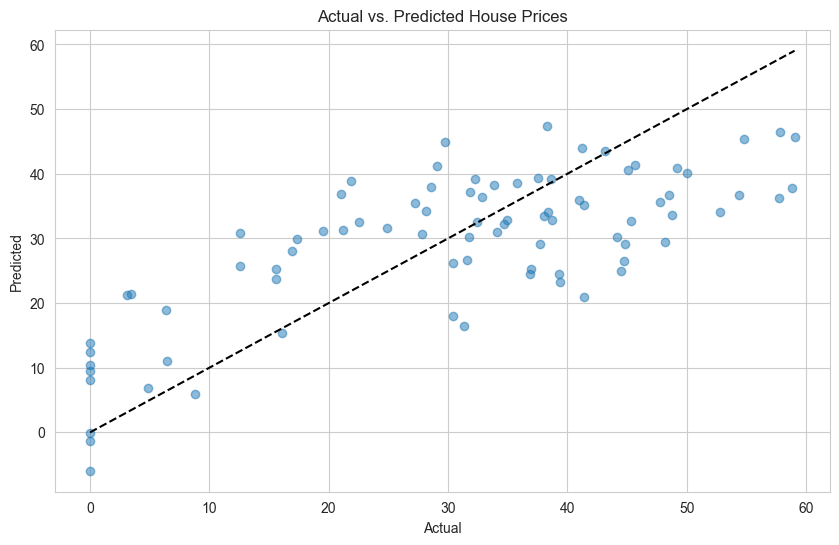

In [46]:
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

features = ['Distance to the nearest MRT station', 'Number of convenience stores', 'Latitude', 'Longitude']
target = 'House price of unit area'

X=df[features].values
y=df[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = make_pipeline(StandardScaler(),LinearRegression())
lr.fit(X_train, y_train)

y_pred=lr.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'k--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted House Prices')
plt.show()


In [47]:
print('MSE:', mean_squared_error(y_test, y_pred))
print('R^2:', r2_score(y_test, y_pred))

MSE: 124.57938927543914
R^2: 0.5496730640945564


In [53]:
from sklearn.tree import DecisionTreeRegressor

dt=DecisionTreeRegressor(
    max_depth=3,      
    min_samples_split=0.2,
    min_samples_leaf=0.006,
    random_state=42
)
dt.fit(X_train,y_train)
y_pred=dt.predict(X_test)
print('MSE:', mean_squared_error(y_test, y_pred))
print('R^2:', r2_score(y_test, y_pred))

MSE: 126.7923441562262
R^2: 0.5416737216948397


In [56]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("MSE (RF):", mean_squared_error(y_test, y_pred))
print("R^2 (RF):", r2_score(y_test, y_pred))

MSE (RF): 129.81370007179268
R^2 (RF): 0.5307521883685797


The dataset is too small and too simple for Random Forests or Decision Trees. Linear Regression is already close to the best we can do with these features.